In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np

In [6]:
df=sns.load_dataset('iris')

In [7]:
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [8]:
columns = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
           'Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']

df = pd.read_csv('pima-indians-diabetes.csv', names=columns)



In [9]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [10]:
duplicates = df.duplicated()
print("Số dòng trùng lặp:", duplicates.sum())

df_cleaned = df.drop_duplicates()
print("Số dòng sau khi loại bỏ trùng lặp:", df_cleaned.shape)

Số dòng trùng lặp: 0
Số dòng sau khi loại bỏ trùng lặp: (768, 9)


In [11]:
physiological_ranges = {
    'Pregnancies': (0, 20),
    'Glucose': (40, 200),
    'BloodPressure': (20, 140),
    'SkinThickness': (5, 99),
    'Insulin': (15, 846),
    'BMI': (15, 60),
    'DiabetesPedigreeFunction': (0.0, 2.5),
    'Age': (10, 100)
}

In [12]:
def detect_physiological_errors(df, physiological_ranges):
    if not isinstance(df, pd.DataFrame):
        raise TypeError('df must be a pandas DataFrame')
    if not isinstance(physiological_ranges, dict):
        raise TypeError('physiological_ranges must be a dict')
    errors = {}
    for col, valid_range in physiological_ranges.items():
        if col not in df.columns:
            continue
        if not (isinstance(valid_range, (tuple, list)) and len(valid_range) == 2):
            raise ValueError(f'Range for {col} must be tuple/list (min, max)')
        min_val, max_val = valid_range
        col_values = df[col]
        invalid_mask = col_values.notna() & ((col_values < min_val) | (col_values > max_val))
        invalid_values = col_values[invalid_mask]
        if not invalid_values.empty:
            errors[col] = {
                'count': int(invalid_values.shape[0]),
                'min_actual': float(col_values.min()) if pd.notna(col_values.min()) else None,
                'max_actual': float(col_values.max()) if pd.notna(col_values.max()) else None,
                'problem_values': sorted(set(invalid_values.tolist()))
            }
    return errors

In [13]:
errors = detect_physiological_errors(df, physiological_ranges)
print("=== Dữ liệu lỗi phát hiện ===")
for col, info in errors.items():
        print(f"{col}: {info['count']} giá trị lỗi")
        print(f" -Range thực tế: {info['min_actual']} - {info['max_actual']}")
        print(f" -Giá trị có vấn đề: {info['problem_values']}")

=== Dữ liệu lỗi phát hiện ===
Glucose: 5 giá trị lỗi
 -Range thực tế: 0.0 - 199.0
 -Giá trị có vấn đề: [0]
BloodPressure: 35 giá trị lỗi
 -Range thực tế: 0.0 - 122.0
 -Giá trị có vấn đề: [0]
SkinThickness: 227 giá trị lỗi
 -Range thực tế: 0.0 - 99.0
 -Giá trị có vấn đề: [0]
Insulin: 375 giá trị lỗi
 -Range thực tế: 0.0 - 846.0
 -Giá trị có vấn đề: [0, 14]
BMI: 12 giá trị lỗi
 -Range thực tế: 0.0 - 67.1
 -Giá trị có vấn đề: [0.0, 67.1]


In [14]:

def handle_zero_values(df):
    zero_sensitive_columns = ['Insulin', 'SkinThickness']
    for col in zero_sensitive_columns:
        zero_mask = df[col] == 0
        if zero_mask.any():
            print(f"Phát hiện {zero_mask.sum()} giá trị 0 trong {col}")
            median_val = df[col][df[col] > 0].median()
            df.loc[zero_mask, col] = median_val
            print(f" -> Đã thay thế bằng median: {median_val:.2f}")
    return df
df_final = handle_zero_values(df_cleaned)

Phát hiện 374 giá trị 0 trong Insulin
 -> Đã thay thế bằng median: 125.00
Phát hiện 227 giá trị 0 trong SkinThickness
 -> Đã thay thế bằng median: 29.00


In [15]:
print("=== KẾT QUẢ SAU XỬ LÝ ===")
print(f"Dữ liệu gốc: {len(df)} dòng")
print(f"Sau xử lý: {len(df_final)} dòng")
print(f"Tỷ lệ giữ lại: {len(df_final)/len(df)*100:.1f}%")
final_errors = detect_physiological_errors(df_final, physiological_ranges)
if not final_errors:
    print("Tất cả dữ liệu đều trong ngưỡng sinh lý hợp lý")
else:
    print("Vẫn còn dữ liệu lỗi:")
    for col, info in final_errors.items():
        print(f" - {col}: {info['count']} lỗi")

=== KẾT QUẢ SAU XỬ LÝ ===
Dữ liệu gốc: 768 dòng
Sau xử lý: 768 dòng
Tỷ lệ giữ lại: 100.0%
Vẫn còn dữ liệu lỗi:
 - Glucose: 5 lỗi
 - BloodPressure: 35 lỗi
 - Insulin: 1 lỗi
 - BMI: 12 lỗi


In [16]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


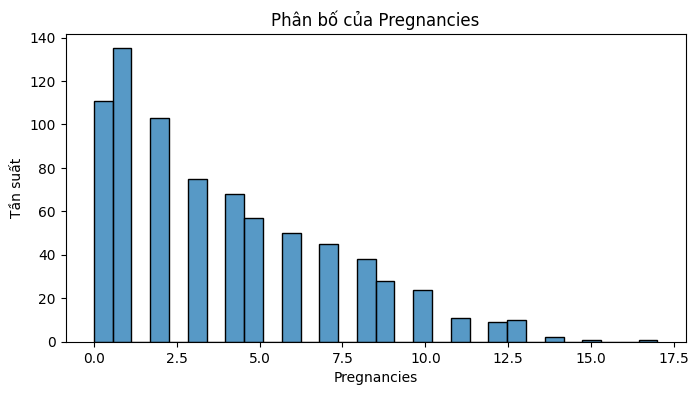

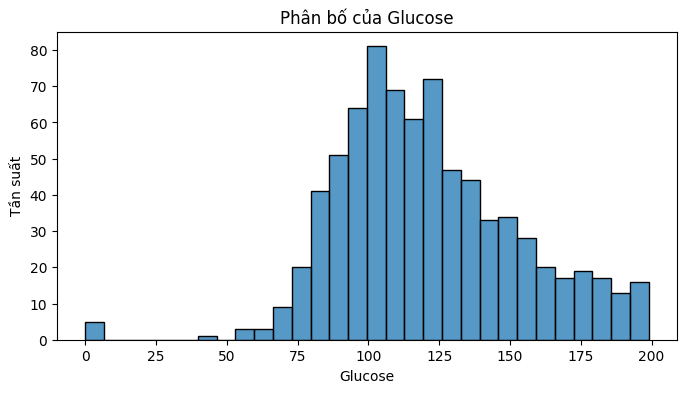

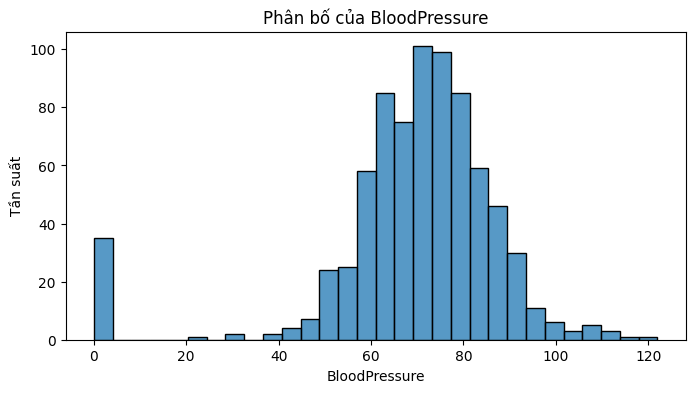

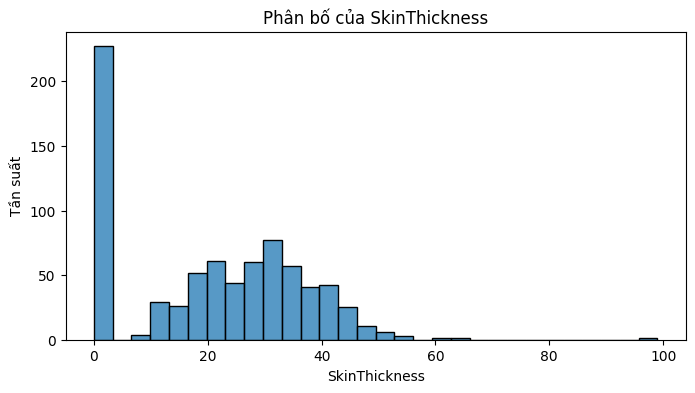

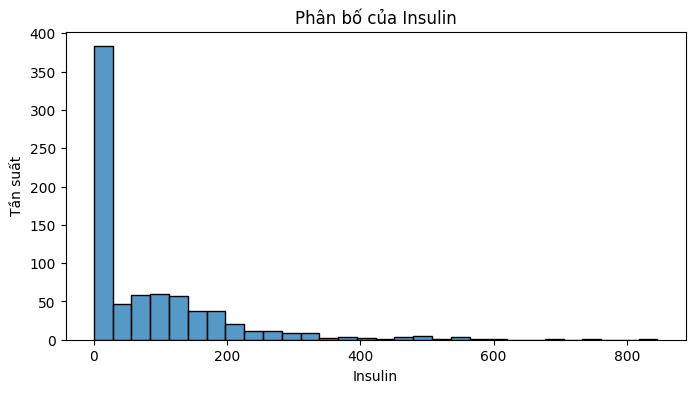

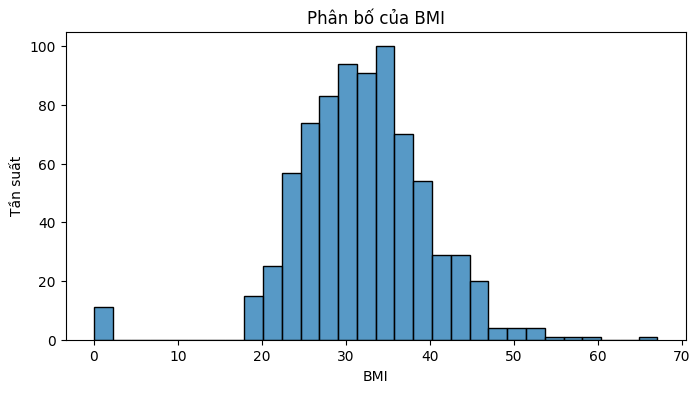

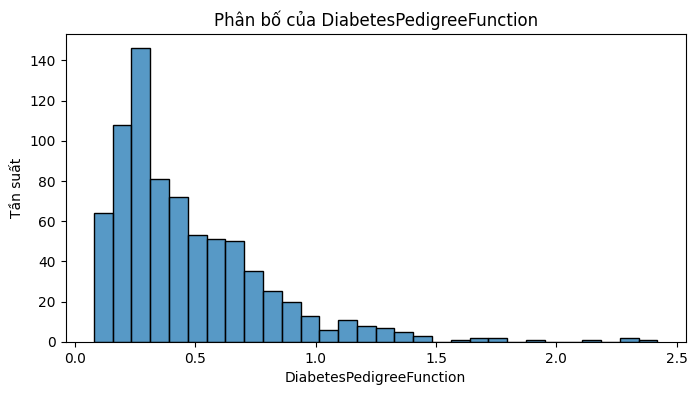

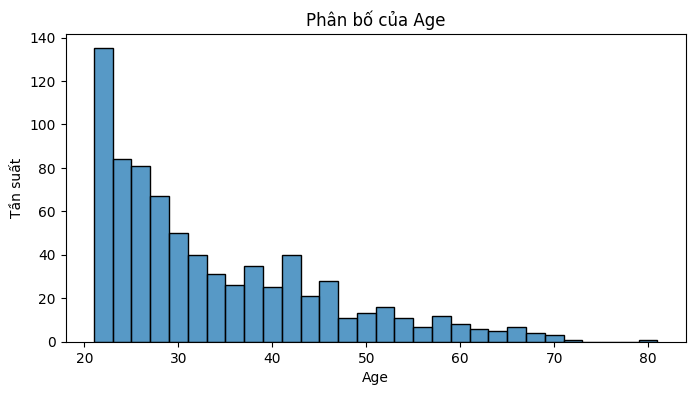

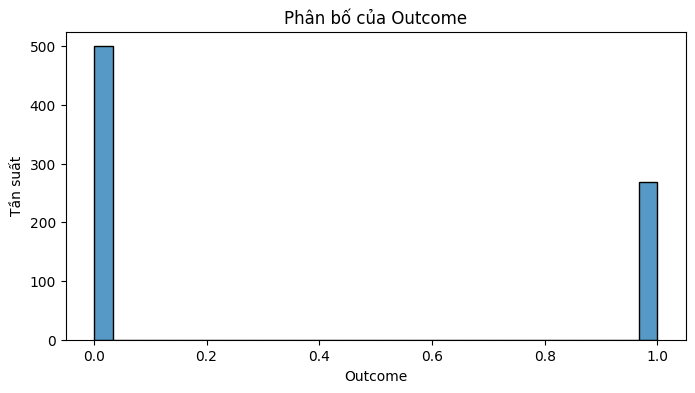

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns


for column in df.columns:
    plt.figure(figsize=(8, 4))
    if df[column].dtype in ['int64', 'float64']:
        sns.histplot(df[column], kde=False, bins=30)
        plt.title(f'Phân bố của {column}')
        plt.xlabel(column)
        plt.ylabel('Tần suất')
    else:
        sns.countplot(x=df[column])
        plt.title(f'Phân bố của {column}')
        plt.xlabel(column)
        plt.ylabel('Số lượng')
    plt.show()

=== PHÁT HIỆN OUTLIERS BẰNG IQR ===
Pregnancies: 4 outliers
  - Giới hạn dưới: -6.50, Giới hạn trên: 13.50
  - Giá trị outliers: [np.int64(14), np.int64(15), np.int64(17)]...

Glucose: 5 outliers
  - Giới hạn dưới: 37.12, Giới hạn trên: 202.12
  - Giá trị outliers: [np.int64(0)]...

BloodPressure: 45 outliers
  - Giới hạn dưới: 35.00, Giới hạn trên: 107.00
  - Giá trị outliers: [np.int64(0), np.int64(24), np.int64(30), np.int64(108), np.int64(110), np.int64(114), np.int64(122)]...

SkinThickness: 87 outliers
  - Giới hạn dưới: 14.50, Giới hạn trên: 42.50
  - Giá trị outliers: [np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(43), np.int64(44), np.int64(45)]...

Insulin: 346 outliers
  - Giới hạn dưới: 112.88, Giới hạn trên: 135.88
  - Giá trị outliers: [np.int64(14), np.int64(15), np.int64(16), np.int64(18), np.int64(22), np.int64(23), np.int64(25), np.int64(29), np.int64(32), np.int64(36)]...

BMI: 19 outliers
  - Giới hạn dưới: 

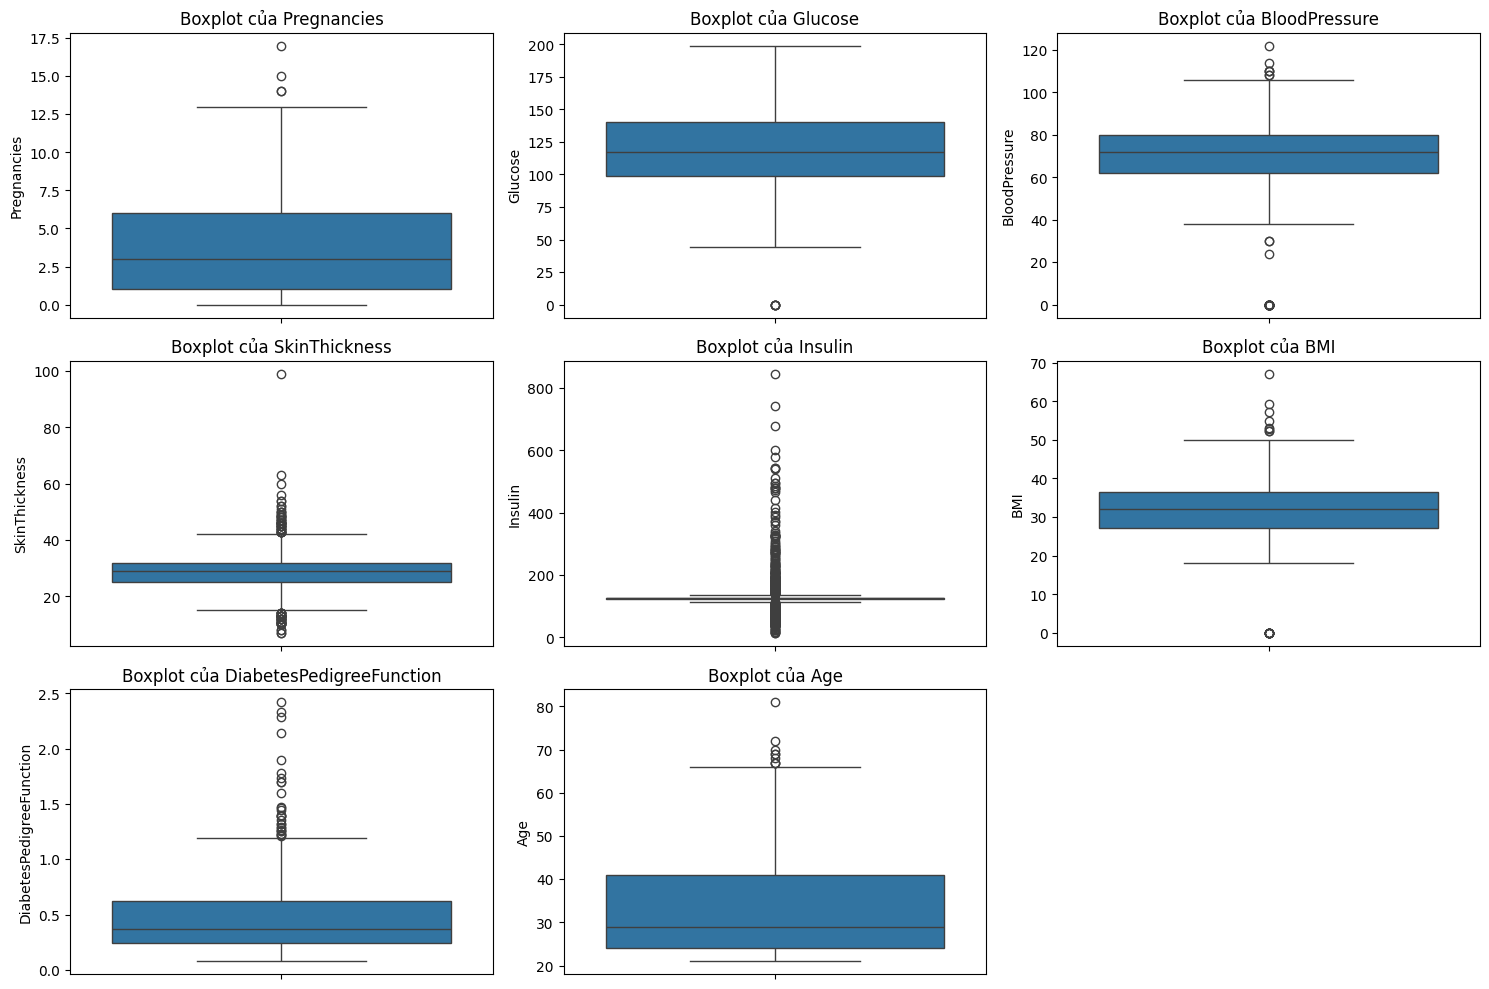

In [18]:
import numpy as np
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound
print("=== PHÁT HIỆN OUTLIERS BẰNG IQR ===")
numeric_columns = df_final.select_dtypes(include=[np.number]).columns
for col in numeric_columns:
    if col != 'Outcome':  
        outliers, lower, upper = detect_outliers_iqr(df_final, col)
        print(f"{col}: {len(outliers)} outliers")
        if len(outliers) > 0:
            print(f"  - Giới hạn dưới: {lower:.2f}, Giới hạn trên: {upper:.2f}")
            print(f"  - Giá trị outliers: {sorted(outliers[col].unique())[:10]}...")  
        print()
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_columns):
    if col != 'Outcome':
        plt.subplot(3, 3, i+1)
        sns.boxplot(y=df_final[col])
        plt.title(f'Boxplot của {col}')
plt.tight_layout()
plt.show()

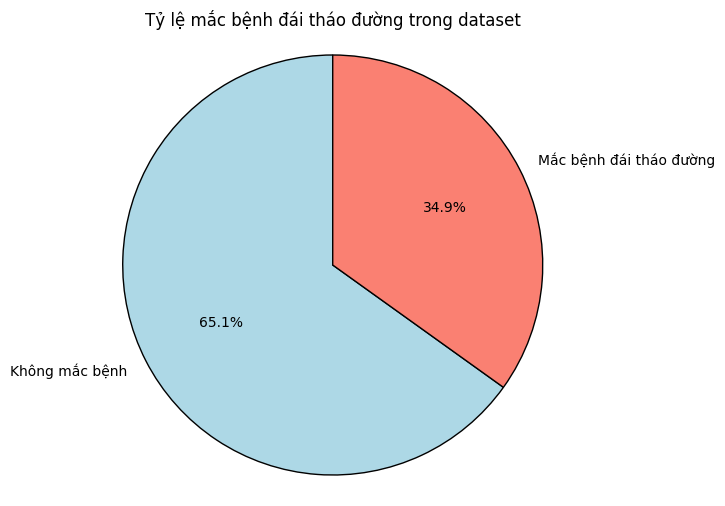

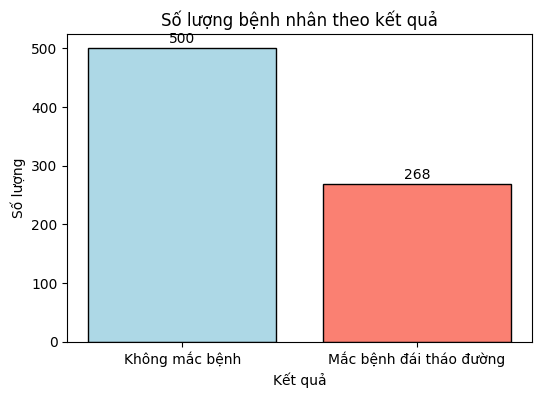

In [19]:
# Vẽ tỷ lệ mắc bệnh đái tháo đường
outcome_counts = df_final['Outcome'].value_counts()
labels = ['Không mắc bệnh', 'Mắc bệnh đái tháo đường']
colors = ['lightblue', 'salmon']

plt.figure(figsize=(8, 6))
plt.pie(outcome_counts, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'black'})
plt.title('Tỷ lệ mắc bệnh đái tháo đường trong dataset')
plt.axis('equal')  # Đảm bảo hình tròn
plt.show()

# Thêm bar chart để so sánh
plt.figure(figsize=(6, 4))
bars = plt.bar(labels, outcome_counts.values, color=colors, edgecolor='black')
plt.title('Số lượng bệnh nhân theo kết quả')
plt.ylabel('Số lượng')
plt.xlabel('Kết quả')
for bar, count in zip(bars, outcome_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(count), ha='center', va='bottom')
plt.show()

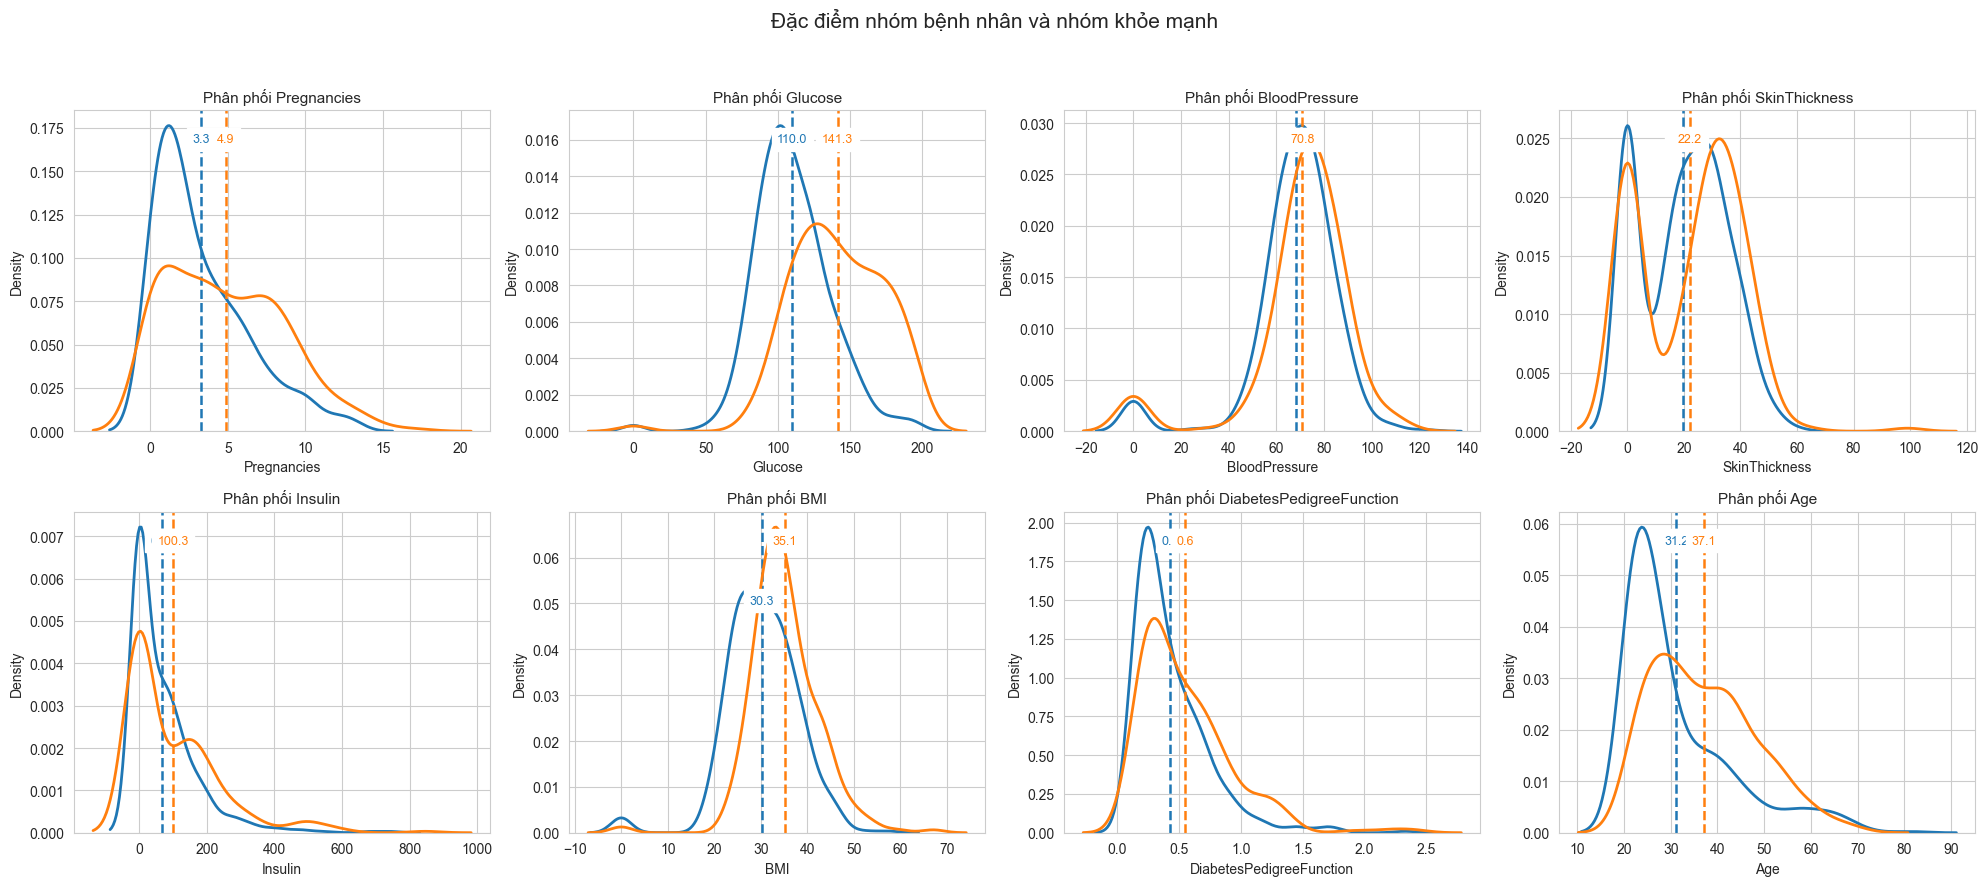

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dữ liệu
columns = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
           'Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']
df = pd.read_csv('pima-indians-diabetes.csv', names=columns)

# Map label
df['Group'] = df['Outcome'].map({0: 'Không mắc', 1: 'Mắc'})

features = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
            'Insulin','BMI','DiabetesPedigreeFunction','Age']

sns.set_style("whitegrid")

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

colors = ['#1f77b4', '#ff7f0e']

for i, col in enumerate(features):
    ax = axes[i]


    for group, color in zip(['Không mắc', 'Mắc'], colors):
        subset = df[df['Group'] == group]

        sns.kdeplot(data=subset,
                    x=col,
                    fill=False,     
                    linewidth=2,
                    color=color,
                    ax=ax)

        # Mean line
        mean_val = subset[col].mean()
        ax.axvline(mean_val,
                   color=color,
                   linestyle='--',
                   linewidth=1.8)

        # Text mean
        ax.text(mean_val,
                ax.get_ylim()[1]*0.9,
                f"{mean_val:.1f}",
                color=color,
                fontsize=9,
                ha='center',
                backgroundcolor='white')

    ax.set_title(f'Phân phối {col}', fontsize=11)
    ax.set_xlabel(col)
    ax.set_ylabel('Density')

plt.suptitle('Đặc điểm nhóm bệnh nhân và nhóm khỏe mạnh', fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

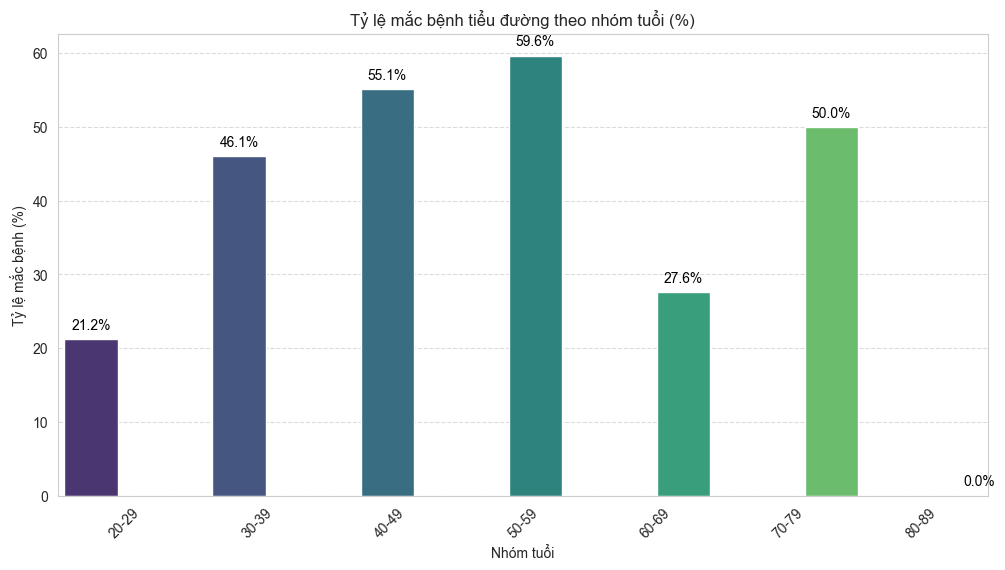

In [21]:
# Phân bố bệnh theo độ tuổi
import matplotlib.pyplot as plt
import seaborn as sns

# Tạo nhóm tuổi
bins = [20, 30, 40, 50, 60, 70, 80, 90]
labels = ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80-89']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

# Tính tỷ lệ mắc bệnh theo nhóm tuổi
age_disease_rate = df.groupby('Age_Group')['Outcome'].mean().reset_index()
age_disease_rate['Outcome'] *= 100  # Chuyển thành phần trăm

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=age_disease_rate,
    x='Age_Group',
    y='Outcome',
    hue='Age_Group',
    palette='viridis',
    legend=False
)

for bar in ax.patches:
    bar.set_width(0.4)

# chỉnh lại vị trí để không bị lệch
for bar in ax.patches:
    bar.set_x(bar.get_x() - 0.05)

plt.title('Tỷ lệ mắc bệnh tiểu đường theo nhóm tuổi (%)')
plt.xlabel('Nhóm tuổi')
plt.ylabel('Tỷ lệ mắc bệnh (%)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Thêm số % trên mỗi cột
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontsize=10, color='black',
                xytext=(0, 5), textcoords='offset points')
    
plt.show()

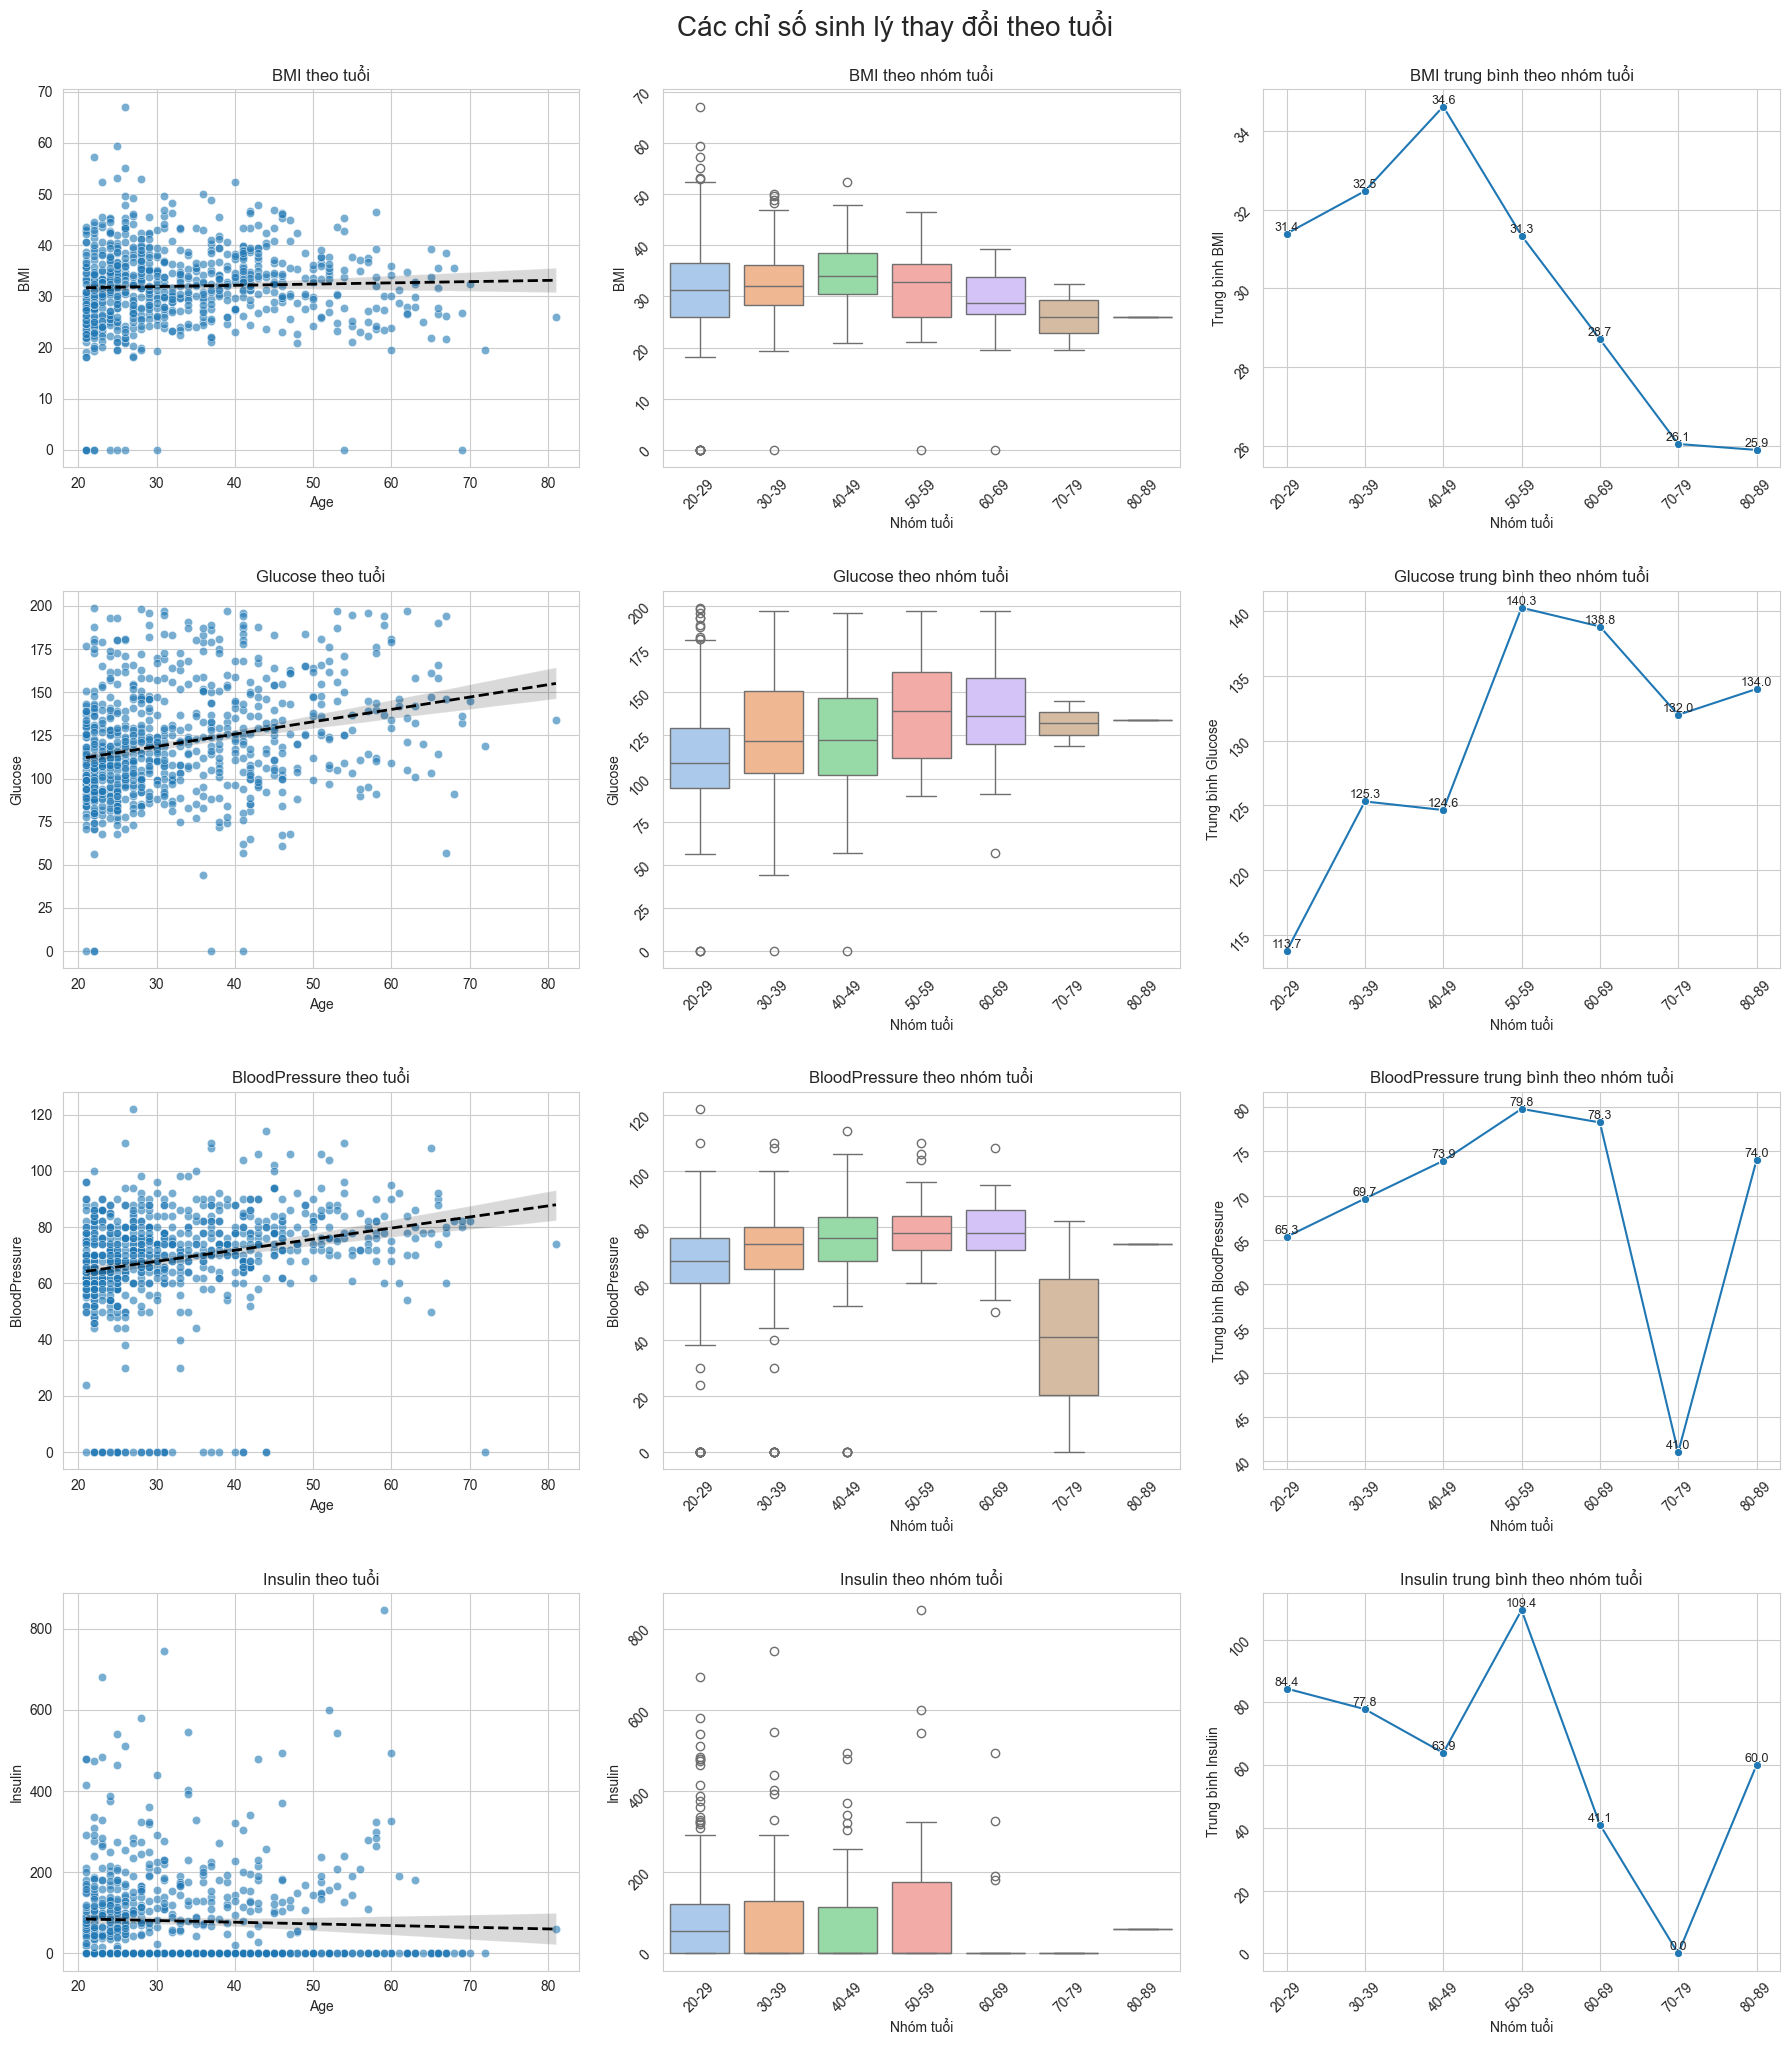

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings("ignore")

columns = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
           'Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']
df = pd.read_csv('pima-indians-diabetes.csv', names=columns)

bins = [20, 30, 40, 50, 60, 70, 80, 90]
labels = ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80-89']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

features = ['BMI', 'Glucose', 'BloodPressure', 'Insulin']

sns.set_style('whitegrid')
fig, axes = plt.subplots(4, 3, figsize=(18, 20))
axes = axes.flatten()

for i, feat in enumerate(features):
    # 1) Scatter + trendline (tất cả data)
    ax = axes[i*3 + 0]
    sns.scatterplot(data=df, x='Age', y=feat, color='#1f77b4', alpha=0.6, ax=ax)
    sns.regplot(data=df, x='Age', y=feat, scatter=False, ax=ax,
                line_kws={'color':'black','lw':2,'ls':'--'})
    ax.set_title(f'{feat} theo tuổi')
    ax.set_xlabel('Age')
    ax.set_ylabel(feat)

    # 2) Boxplot theo nhóm tuổi
    ax = axes[i*3 + 1]
    sns.boxplot(data=df, x='Age_Group', y=feat, ax=ax, palette='pastel')
    ax.set_title(f'{feat} theo nhóm tuổi')
    ax.set_xlabel('Nhóm tuổi')
    ax.set_ylabel(feat)
    ax.tick_params(rotation=45)

    # 3) Trung bình theo nhóm tuổi
    avg = df.groupby('Age_Group')[feat].mean().reset_index()
    ax = axes[i*3 + 2]
    sns.lineplot(data=avg, x='Age_Group', y=feat, marker='o', ax=ax, color='tab:blue')
    ax.set_title(f'{feat} trung bình theo nhóm tuổi')
    ax.set_xlabel('Nhóm tuổi')
    ax.set_ylabel(f'Trung bình {feat}')
    ax.tick_params(rotation=45)
    for x, y in zip(avg['Age_Group'], avg[feat]):
        ax.text(x, y, f'{y:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout(h_pad=2.5, w_pad=2)
plt.suptitle('Các chỉ số sinh lý thay đổi theo tuổi', fontsize=20, y=1.02)
plt.show()

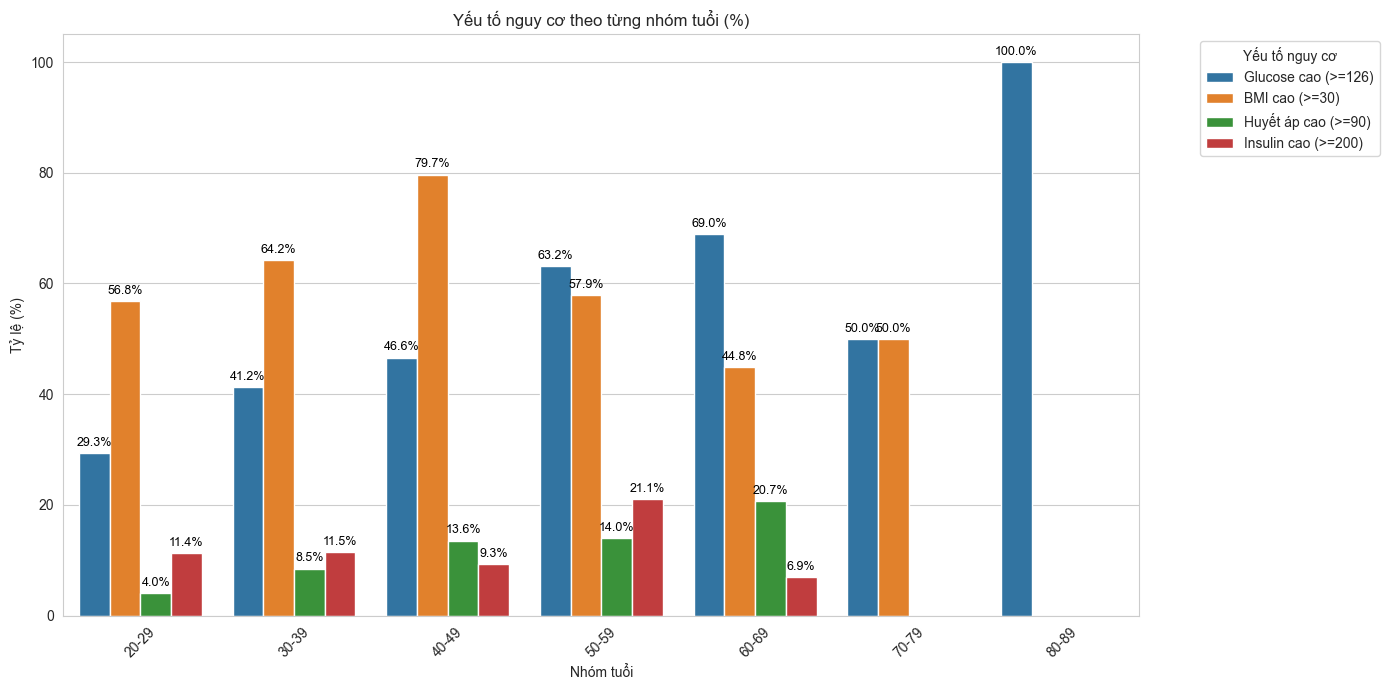

In [23]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
columns = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
           'Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']
df = pd.read_csv('pima-indians-diabetes.csv', names=columns)

# Nhóm tuổi
bins = [20, 30, 40, 50, 60, 70, 80, 90]
labels = ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80-89']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

# Định nghĩa yếu tố nguy cơ
df['Risk_Glucose'] = (df['Glucose'] >= 126).astype(int)
df['Risk_BMI'] = (df['BMI'] >= 30).astype(int)
df['Risk_BP'] = (df['BloodPressure'] >= 90).astype(int)  # hoặc 80 tùy chọn
df['Risk_Insulin'] = (df['Insulin'] >= 200).astype(int)  # hội chẩn đặc trưng

# Tính phần trăm theo nhóm tuổi
risk_df = df.groupby('Age_Group')[['Risk_Glucose','Risk_BMI','Risk_BP','Risk_Insulin']].mean() * 100
risk_df = risk_df.reset_index()

# Chuyển long format cho seaborn
risk_melt = risk_df.melt(id_vars='Age_Group',
                         value_vars=['Risk_Glucose','Risk_BMI','Risk_BP','Risk_Insulin'],
                         var_name='Risk_Factor',
                         value_name='Percent')

# Nhãn đẹp hơn
risk_melt['Risk_Factor'] = risk_melt['Risk_Factor'].map({
    'Risk_Glucose': 'Glucose cao (>=126)',
    'Risk_BMI': 'BMI cao (>=30)',
    'Risk_BP': 'Huyết áp cao (>=90)',
    'Risk_Insulin': 'Insulin cao (>=200)'
})

sns.set_style('whitegrid')
plt.figure(figsize=(14, 7))
sns.barplot(data=risk_melt, x='Age_Group', y='Percent', hue='Risk_Factor', palette='tab10')

plt.title('Yếu tố nguy cơ theo từng nhóm tuổi (%)')
plt.xlabel('Nhóm tuổi')
plt.ylabel('Tỷ lệ (%)')
plt.legend(title='Yếu tố nguy cơ', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)

# Ghi số phần trăm trên cột
ax = plt.gca()
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f'{h:.1f}%', (p.get_x() + p.get_width() / 2, h),
                    ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 3),
                    textcoords='offset points')

plt.tight_layout()
plt.show()

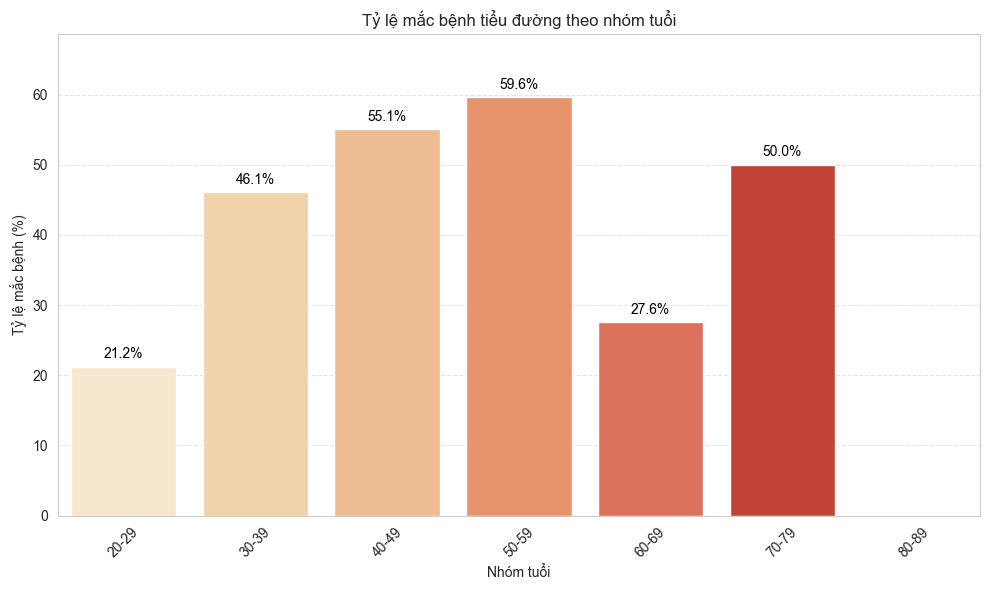

In [24]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

columns = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
           'Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']
df = pd.read_csv('pima-indians-diabetes.csv', names=columns)

# Nhóm tuổi
bins = [20, 30, 40, 50, 60, 70, 80, 90]
labels = ['20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80-89']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

# Tỷ lệ mắc bệnh theo nhóm tuổi
age_disease_rate = (
    df.groupby('Age_Group')['Outcome']
      .mean()
      .reset_index(name='Diabetes_Rate')
)
age_disease_rate['Diabetes_Rate'] *= 100

# (Tùy chọn) chỉ lấy nhóm có dữ liệu
age_disease_rate = age_disease_rate.dropna()

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=age_disease_rate,
    x='Age_Group',
    y='Diabetes_Rate',
    palette='OrRd'
)

for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f'{h:.1f}%', 
                    (p.get_x() + p.get_width() / 2, h),
                    ha='center', va='bottom',
                    fontsize=10, color='black', xytext=(0, 4),
                    textcoords='offset points')

ax.set_title('Tỷ lệ mắc bệnh tiểu đường theo nhóm tuổi')
ax.set_xlabel('Nhóm tuổi')
ax.set_ylabel('Tỷ lệ mắc bệnh (%)')
ax.set_ylim(0, age_disease_rate['Diabetes_Rate'].max() * 1.15)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Chương 5:

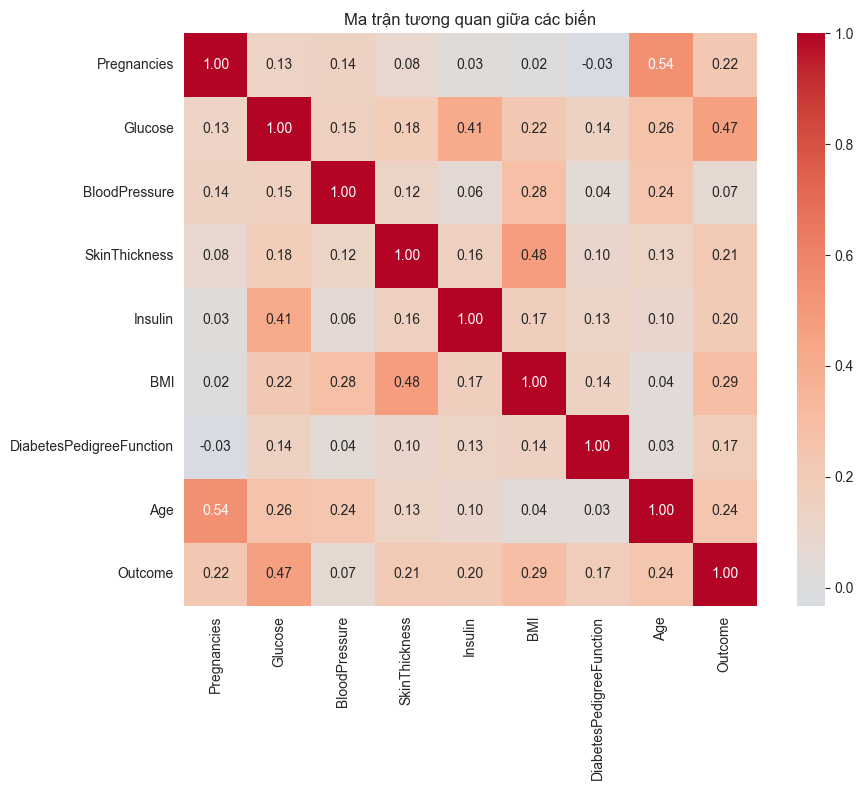

In [ ]:
# 5.1 Ma trận tương quan

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
from sklearn.feature_selection import chi2, mutual_info_classif
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

plt.figure(figsize=(10, 8))
corr = df_final.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Ma trận tương quan giữa các biến")
plt.tight_layout()
plt.show()

In [ ]:
# 5.2 Phân tích cặp biến quan trọng

def prop_positive_above_threshold(df, col, thresholds, target='Outcome'):
    vals = []
    for thr in thresholds:
        sub = df[df[col] >= thr]
        if len(sub) == 0:
            vals.append(0)
        else:
            vals.append(round((sub[target].mean() * 100), 1))
    return vals

def make_interval_labels(series, bins=5):
    cat = pd.cut(series, bins=bins)
    return cat


5.2.1. Glucose - Kết quả bệnh
Hệ số tương quan Pearson: 0.47


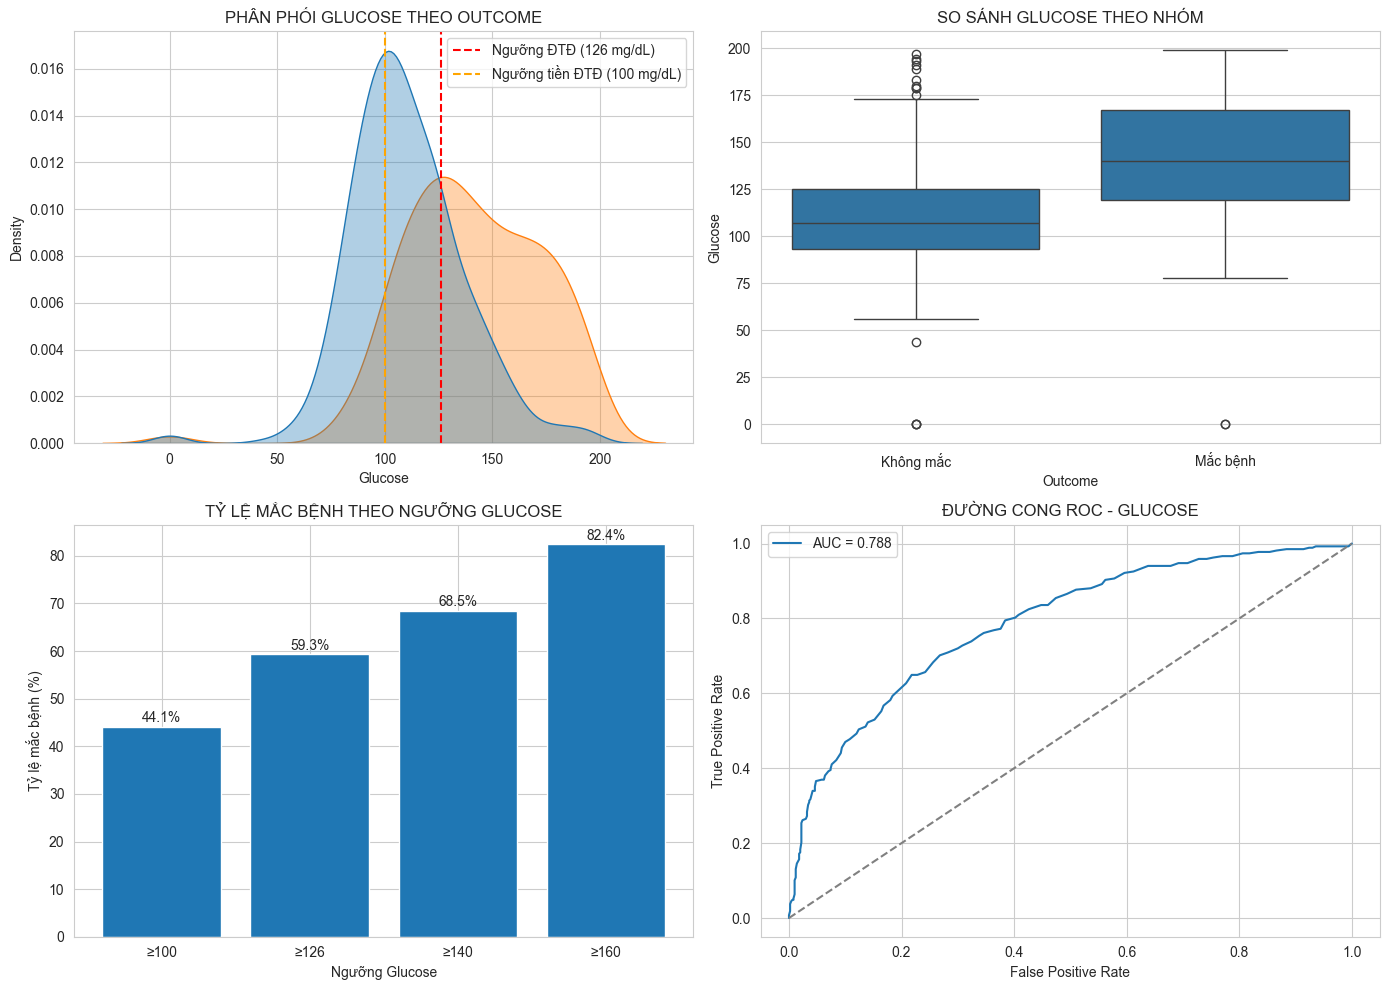

In [50]:
# 5.2.1. Glucose - Kết quả bệnh

corr_glucose_outcome = df_final[['Glucose', 'Outcome']].corr().iloc[0, 1]
print("5.2.1. Glucose - Kết quả bệnh")
print(f"Hệ số tương quan Pearson: {corr_glucose_outcome:.2f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Phân phối Glucose theo Outcome
sns.kdeplot(
    data=df_final, x='Glucose', hue='Outcome',
    fill=True, common_norm=False, alpha=0.35, ax=axes[0, 0]
)
axes[0, 0].axvline(126, color='red', linestyle='--', linewidth=1.5, label='Ngưỡng ĐTĐ (126 mg/dL)')
axes[0, 0].axvline(100, color='orange', linestyle='--', linewidth=1.5, label='Ngưỡng tiền ĐTĐ (100 mg/dL)')
axes[0, 0].set_title('PHÂN PHỐI GLUCOSE THEO OUTCOME')
axes[0, 0].set_xlabel('Glucose')
axes[0, 0].set_ylabel('Density')
axes[0, 0].legend()

# 2) Boxplot so sánh Glucose theo nhóm
sns.boxplot(data=df_final, x='Outcome', y='Glucose', order=[0, 1], ax=axes[0, 1])
axes[0, 1].set_title('SO SÁNH GLUCOSE THEO NHÓM')
axes[0, 1].set_xlabel('Outcome')
axes[0, 1].set_ylabel('Glucose')
axes[0, 1].set_xticklabels(['Không mắc', 'Mắc bệnh'])

# 3) Tỷ lệ mắc bệnh theo ngưỡng Glucose
thresholds = [100, 126, 140, 160]
rate_values = prop_positive_above_threshold(df_final, 'Glucose', thresholds)
bar_labels = ['≥100', '≥126', '≥140', '≥160']

axes[1, 0].bar(bar_labels, rate_values)
axes[1, 0].set_title('TỶ LỆ MẮC BỆNH THEO NGƯỠNG GLUCOSE')
axes[1, 0].set_xlabel('Ngưỡng Glucose')
axes[1, 0].set_ylabel('Tỷ lệ mắc bệnh (%)')
for i, v in enumerate(rate_values):
    axes[1, 0].text(i, v + 1, f'{v:.1f}%', ha='center')

# 4) ROC của Glucose
Xg = df_final[['Glucose']].values
y = df_final['Outcome'].values
model_g = LogisticRegression(max_iter=1000)
model_g.fit(Xg, y)
prob_g = model_g.predict_proba(Xg)[:, 1]
fpr_g, tpr_g, _ = roc_curve(y, prob_g)
auc_g = auc(fpr_g, tpr_g)

axes[1, 1].plot(fpr_g, tpr_g, label=f'AUC = {auc_g:.3f}')
axes[1, 1].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1, 1].set_title('ĐƯỜNG CONG ROC - GLUCOSE')
axes[1, 1].set_xlabel('False Positive Rate')
axes[1, 1].set_ylabel('True Positive Rate')
axes[1, 1].legend()

plt.tight_layout()
plt.show()




5.2.2. BMI - Độ dày da
Hệ số tương quan Pearson: 0.482


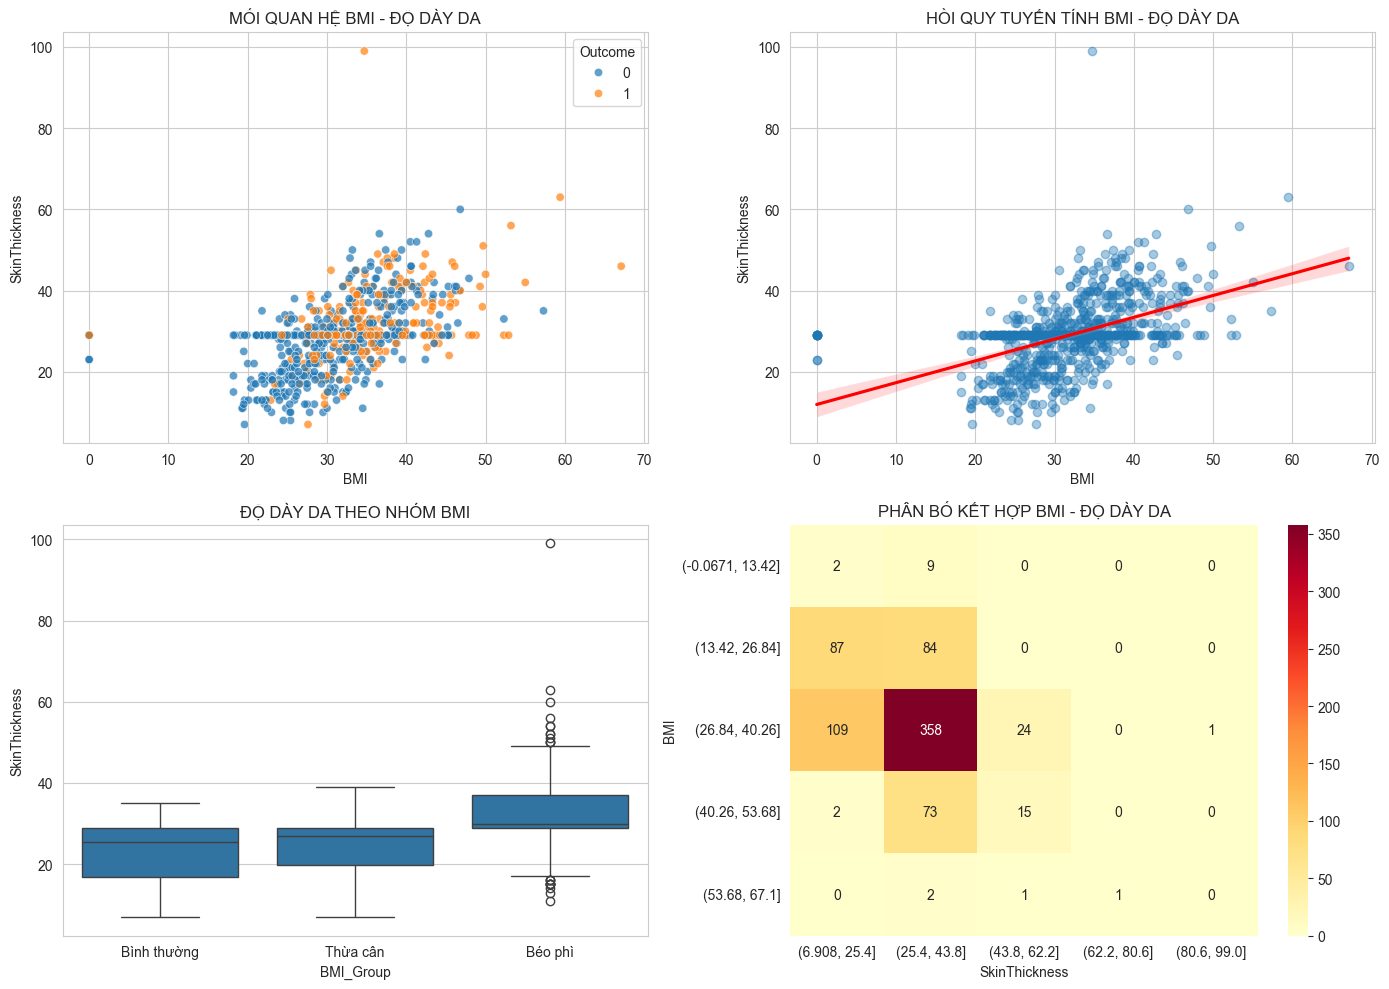

In [52]:
# 5.2.2. BMI - Độ dày da

corr_bmi_skin = df_final[['BMI', 'SkinThickness']].corr().iloc[0, 1]
print("\n5.2.2. BMI - Độ dày da")
print(f"Hệ số tương quan Pearson: {corr_bmi_skin:.3f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Scatter BMI - SkinThickness theo Outcome
sns.scatterplot(data=df_final, x='BMI', y='SkinThickness', hue='Outcome', ax=axes[0, 0], alpha=0.7)
axes[0, 0].set_title('MỐI QUAN HỆ BMI - ĐỘ DÀY DA')
axes[0, 0].set_xlabel('BMI')
axes[0, 0].set_ylabel('SkinThickness')

# 2) Hồi quy tuyến tính BMI - SkinThickness
sns.regplot(data=df_final, x='BMI', y='SkinThickness',
            scatter_kws={'alpha': 0.4}, line_kws={'color': 'red'}, ax=axes[0, 1])
axes[0, 1].set_title('HỒI QUY TUYẾN TÍNH BMI - ĐỘ DÀY DA')
axes[0, 1].set_xlabel('BMI')
axes[0, 1].set_ylabel('SkinThickness')

# 3) Boxplot SkinThickness theo nhóm BMI
df_final['BMI_Group'] = pd.cut(df_final['BMI'], bins=[0, 25, 30, 100],
                               labels=['Bình thường', 'Thừa cân', 'Béo phì'])
sns.boxplot(data=df_final, x='BMI_Group', y='SkinThickness', ax=axes[1, 0])
axes[1, 0].set_title('ĐỘ DÀY DA THEO NHÓM BMI')
axes[1, 0].set_xlabel('BMI_Group')
axes[1, 0].set_ylabel('SkinThickness')

# 4) Heatmap BMI - SkinThickness
df_final['BMI_bin'] = pd.cut(df_final['BMI'], bins=5)
df_final['Skin_bin'] = pd.cut(df_final['SkinThickness'], bins=5)
heat_bmi_skin = pd.crosstab(df_final['BMI_bin'], df_final['Skin_bin'])

sns.heatmap(heat_bmi_skin, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1, 1])
axes[1, 1].set_title('PHÂN BỐ KẾT HỢP BMI - ĐỘ DÀY DA')
axes[1, 1].set_xlabel('SkinThickness')
axes[1, 1].set_ylabel('BMI')

plt.tight_layout()
plt.show()


5.2.3. Tuổi - Số lần có thai
Hệ số tương quan Pearson: 0.544


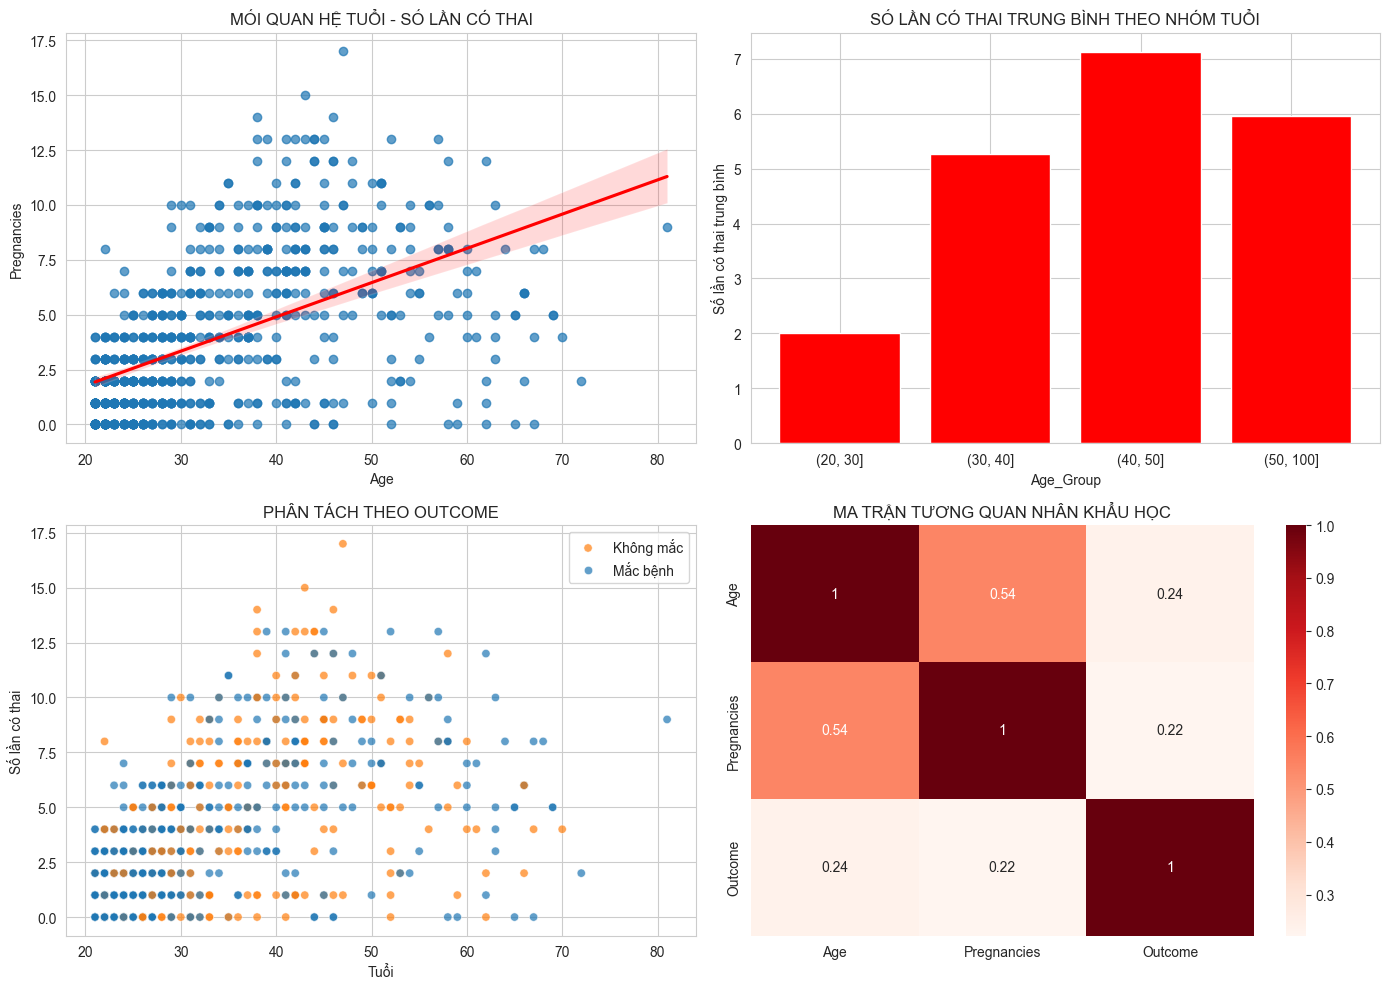

In [61]:
# 5.2.3. Tuổi - Số lần có thai

corr_age_preg = df_final[['Age', 'Pregnancies']].corr().iloc[0, 1]
print("\n5.2.3. Tuổi - Số lần có thai")
print(f"Hệ số tương quan Pearson: {corr_age_preg:.3f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Scatter Age - Pregnancies
sns.regplot(data=df_final, x='Age', y='Pregnancies',
                scatter_kws={"alpha":0.7}, line_kws={"color":"red"}, ax=axes[0, 0])
axes[0, 0].set_title('MỐI QUAN HỆ TUỔI - SỐ LẦN CÓ THAI')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Pregnancies')

# 2) Số lần có thai trung bình theo nhóm tuổi
df_final['Age_Group'] = pd.cut(df_final['Age'], bins=[20, 30, 40, 50, 100], right=True)
mean_preg_by_age = df_final.groupby('Age_Group', observed=False)['Pregnancies'].mean()
axes[0, 1].bar([str(x) for x in mean_preg_by_age.index], mean_preg_by_age.values, color='red')
axes[0, 1].set_title('SỐ LẦN CÓ THAI TRUNG BÌNH THEO NHÓM TUỔI')
axes[0, 1].set_xlabel('Age_Group')
axes[0, 1].set_ylabel('Số lần có thai trung bình')

# 3) Phân tách theo Outcome
sns.scatterplot(data=df_final, x='Age', y='Pregnancies', hue='Outcome', ax=axes[1, 0], alpha=0.7)
axes[1, 0].set_title('PHÂN TÁCH THEO OUTCOME')
axes[1, 0].set_xlabel('Tuổi')
axes[1, 0].set_ylabel('Số lần có thai')
axes[1, 0].legend(title='', labels=['Không mắc', 'Mắc bệnh'])

# 4) Heatmap tương quan nhân khẩu học
demo_corr = df_final[['Age', 'Pregnancies', 'Outcome']].corr()
sns.heatmap(demo_corr, annot=True, cmap='Reds', ax=axes[1, 1])
axes[1, 1].set_title('MA TRẬN TƯƠNG QUAN NHÂN KHẨU HỌC')

plt.tight_layout()
plt.show()



5.2.4. Glucose - Insulin
Hệ số tương quan Pearson: 0.409


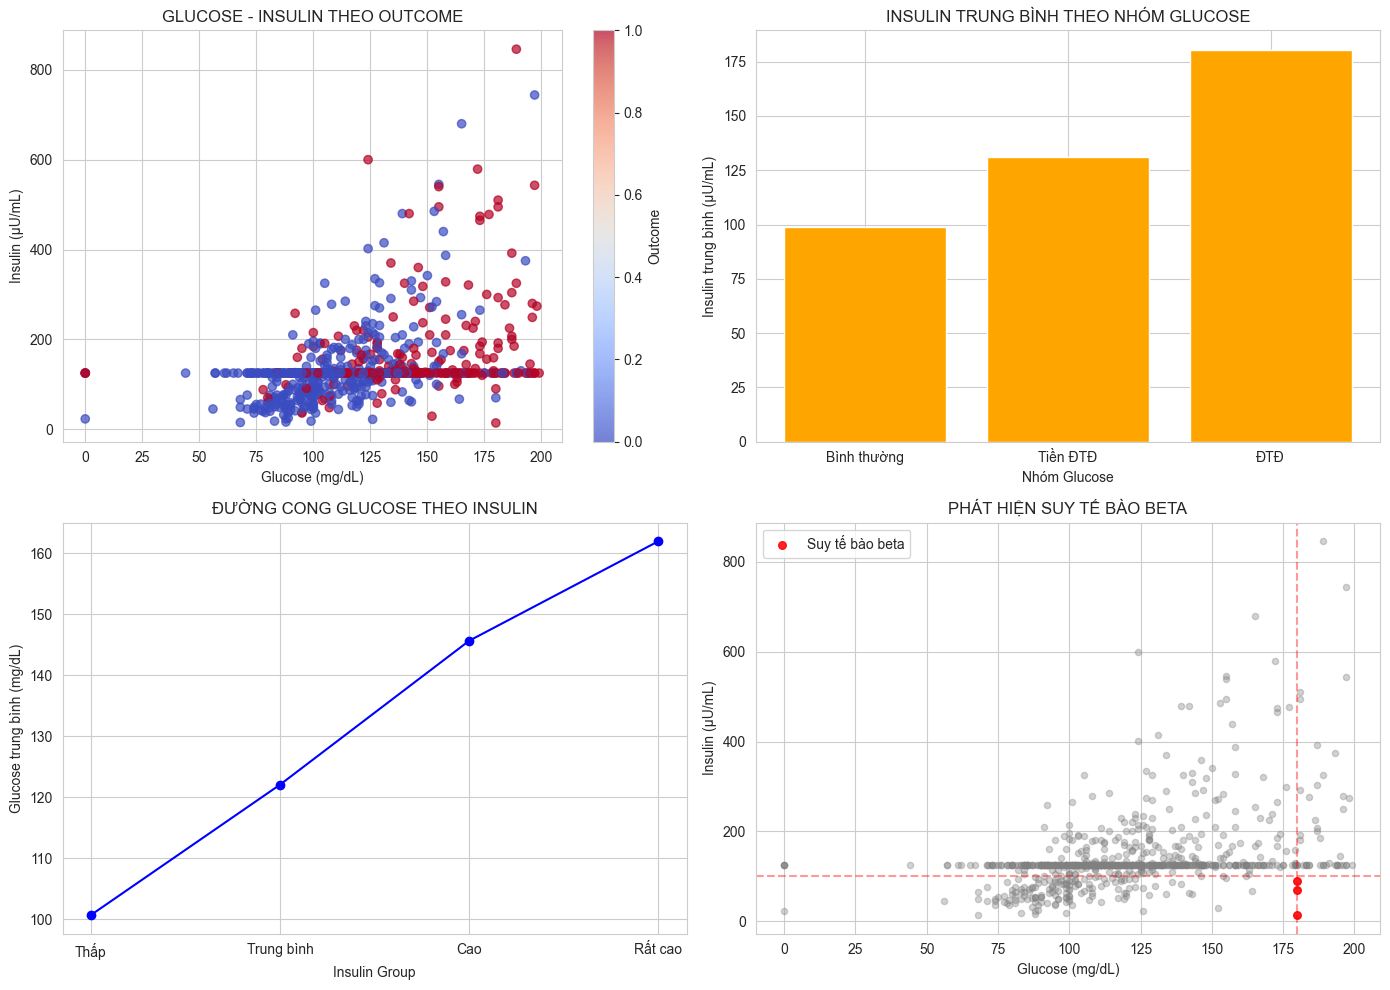

In [54]:
# 5.2.4. Glucose - Insulin

corr_glu_ins = df_final[['Glucose', 'Insulin']].corr().iloc[0, 1]
print("\n5.2.4. Glucose - Insulin")
print(f"Hệ số tương quan Pearson: {corr_glu_ins:.3f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Scatter Glucose - Insulin theo Outcome với colorbar
sc = axes[0, 0].scatter(df_final['Glucose'], df_final['Insulin'],
                        c=df_final['Outcome'], cmap='coolwarm', alpha=0.7)
axes[0, 0].set_title('GLUCOSE - INSULIN THEO OUTCOME')
axes[0, 0].set_xlabel('Glucose (mg/dL)')
axes[0, 0].set_ylabel('Insulin (µU/mL)')
cbar = plt.colorbar(sc, ax=axes[0, 0])
cbar.set_label('Outcome')

# 2) Insulin trung bình theo nhóm Glucose
df_final['Glucose_Group'] = pd.cut(df_final['Glucose'], bins=[0, 100, 126, 200],
                                   labels=['Bình thường', 'Tiền ĐTĐ', 'ĐTĐ'], include_lowest=True)
mean_ins_by_glu = df_final.groupby('Glucose_Group', observed=False)['Insulin'].mean()
axes[0, 1].bar(mean_ins_by_glu.index.astype(str), mean_ins_by_glu.values, color='orange')
axes[0, 1].set_title('INSULIN TRUNG BÌNH THEO NHÓM GLUCOSE')
axes[0, 1].set_xlabel('Nhóm Glucose')
axes[0, 1].set_ylabel('Insulin trung bình (µU/mL)')

# 3) Đường cong Glucose theo Insulin
df_final['Insulin_Group'] = pd.cut(df_final['Insulin'], bins=[0, 100, 200, 400, 1000],
                                   labels=['Thấp', 'Trung bình', 'Cao', 'Rất cao'], include_lowest=True)
mean_glu_by_ins = df_final.groupby('Insulin_Group', observed=False)['Glucose'].mean()
axes[1, 0].plot(mean_glu_by_ins.index.astype(str), mean_glu_by_ins.values, color='blue', marker='o')
axes[1, 0].set_title('ĐƯỜNG CONG GLUCOSE THEO INSULIN')
axes[1, 0].set_xlabel('Insulin Group')
axes[1, 0].set_ylabel('Glucose trung bình (mg/dL)')

# 4) Phát hiện suy tế bào beta
axes[1, 1].scatter(df_final['Glucose'], df_final['Insulin'], color='gray', alpha=0.35, s=20)
beta_fail = (df_final['Glucose'] >= 180) & (df_final['Insulin'] <= 100)
axes[1, 1].scatter(df_final.loc[beta_fail, 'Glucose'],
                   df_final.loc[beta_fail, 'Insulin'],
                   color='red', alpha=0.85, s=30, label='Suy tế bào beta')
axes[1, 1].axvline(180, color='red', linestyle='--', alpha=0.4)
axes[1, 1].axhline(100, color='red', linestyle='--', alpha=0.4)
axes[1, 1].set_title('PHÁT HIỆN SUY TẾ BÀO BETA')
axes[1, 1].set_xlabel('Glucose (mg/dL)')
axes[1, 1].set_ylabel('Insulin (µU/mL)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

5.3.1. Tầm quan trọng đơn biến (C-square)

Bảng 5.1. Tập C-square
                 Feature  Chi_square  p_value
                     Age    8.205691 0.004176
                 Glucose    7.094910 0.007730
             Pregnancies    6.559982 0.010430
DiabetesPedigreeFunction    2.758584 0.096734
                 Insulin    2.255362 0.133152
                     BMI    1.902673 0.167779
           SkinThickness    1.345611 0.246047
           BloodPressure    0.144306 0.704037


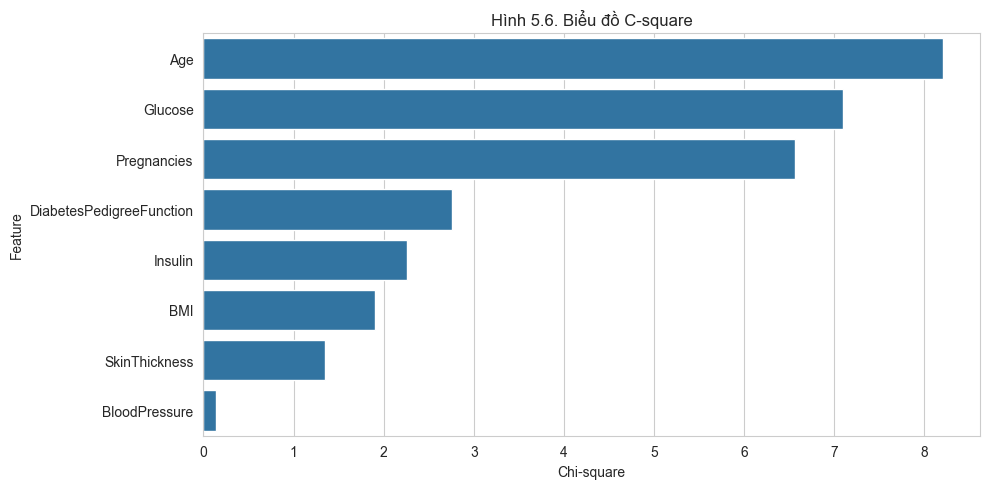


5.3.2. Điểm thông tin tương hỗ

Bảng 5.2. Thông tin tương hỗ
                 Feature  Mutual_Info
                 Glucose     0.114634
                     BMI     0.080061
             Pregnancies     0.060985
                     Age     0.051395
DiabetesPedigreeFunction     0.014590
                 Insulin     0.012804
           SkinThickness     0.012372
           BloodPressure     0.000000

Chỉ số Glucose là cao nhất.

5.3.3. Tầm quan trọng từ Random Forest

Bảng 5.3. Tầm quan trọng của đặc trưng
                 Feature  Importance
                 Glucose    0.255059
                     BMI    0.170064
                     Age    0.135561
DiabetesPedigreeFunction    0.117967
                 Insulin    0.089958
           BloodPressure    0.082278
             Pregnancies    0.074625
           SkinThickness    0.074488


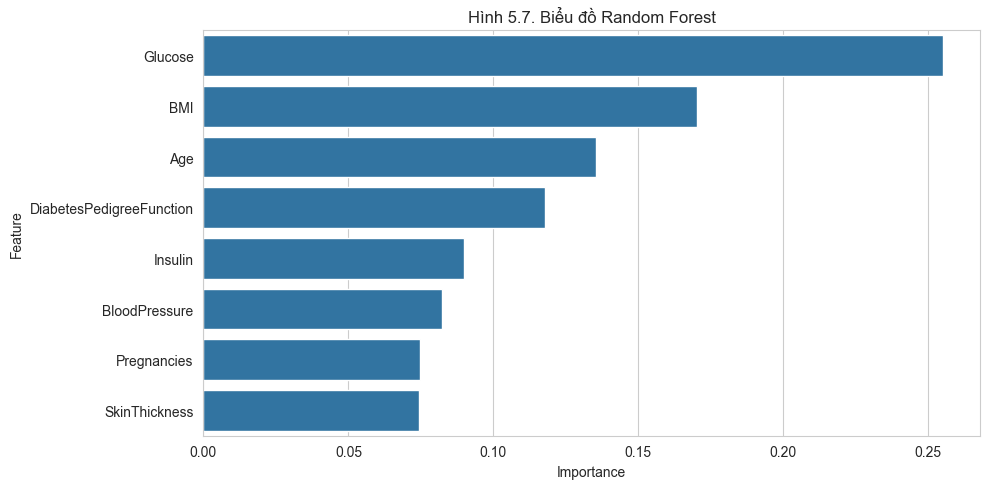

In [69]:
# 5.3 Phân tích tầm quan trọng của đặc trưng

sns.set_style("whitegrid")

base_cols = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'
]

df_model = df_final[base_cols + ['Outcome']].copy()
X = df_model[base_cols]
y = df_model['Outcome']

# 5.3.1. Tầm quan trọng đơn biến - C-square (chi-square)
print("5.3.1. Tầm quan trọng đơn biến (C-square)")

# chi2 yêu cầu dữ liệu không âm -> scale về [0, 1]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

chi2_scores, chi2_pvals = chi2(X_scaled, y)

chi2_df = pd.DataFrame({
    'Feature': base_cols,
    'Chi_square': chi2_scores,
    'p_value': chi2_pvals
}).sort_values('Chi_square', ascending=False)

print("\nBảng 5.1. Tập C-square")
print(chi2_df.to_string(index=False))

plt.figure(figsize=(10, 5))
sns.barplot(data=chi2_df, x='Chi_square', y='Feature')
plt.title('Hình 5.6. Biểu đồ C-square')
plt.xlabel('Chi-square')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# 5.3.2. Điểm thông tin tương hỗ
print("\n5.3.2. Điểm thông tin tương hỗ")

mi_scores = mutual_info_classif(X, y, random_state=42)
mi_df = pd.DataFrame({
    'Feature': base_cols,
    'Mutual_Info': mi_scores
}).sort_values('Mutual_Info', ascending=False)

print("\nBảng 5.2. Thông tin tương hỗ")
print(mi_df.to_string(index=False))

print(f"\nChỉ số {mi_df.iloc[0]['Feature']} là cao nhất.")

# 5.3.3. Tầm quan trọng từ Random Forest
print("\n5.3.3. Tầm quan trọng từ Random Forest")

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced'
)
rf.fit(X, y)

rf_df = pd.DataFrame({
    'Feature': base_cols,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nBảng 5.3. Tầm quan trọng của đặc trưng")
print(rf_df.to_string(index=False))

plt.figure(figsize=(10, 5))
sns.barplot(data=rf_df, x='Importance', y='Feature')
plt.title('Hình 5.7. Biểu đồ Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


5.4. Phát hiện đa cộng tuyến

Bảng 5.1. Bảng hệ số phóng đại phương sai
                 Feature      VIF
                     Age 1.566980
                     BMI 1.451927
             Pregnancies 1.428762
           SkinThickness 1.335792
                 Glucose 1.327387
                 Insulin 1.221885
           BloodPressure 1.157125
DiabetesPedigreeFunction 1.041962


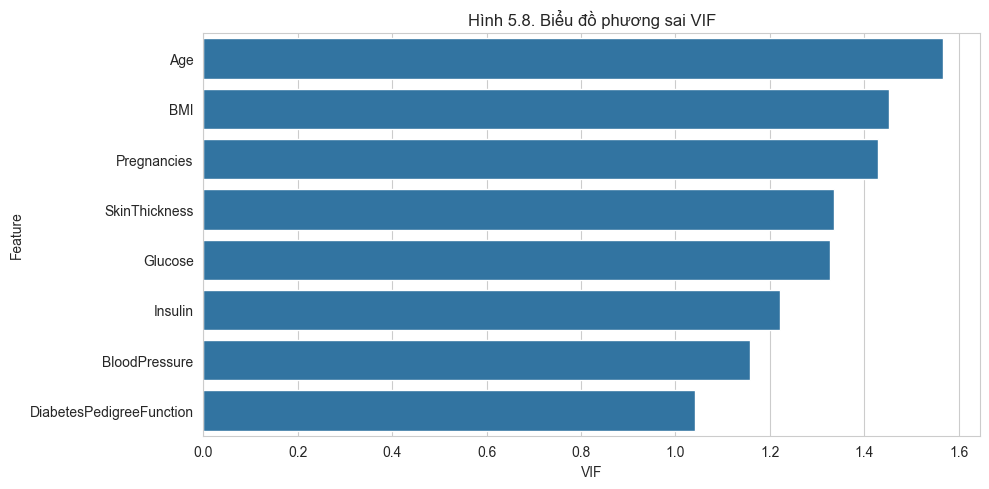

In [ ]:
# 5.4. PHÁT HIỆN ĐA CỘNG TUYẾN - VIF

print("\n5.4. Phát hiện đa cộng tuyến")

X_vif = sm.add_constant(X)
vif_df = pd.DataFrame({
    'Feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})

vif_df_no_const = vif_df[vif_df['Feature'] != 'const'].copy().sort_values('VIF', ascending=False)

print("\nBảng 5.1. Bảng hệ số phóng đại phương sai")
print(vif_df_no_const.to_string(index=False))

plt.figure(figsize=(10, 5))
sns.barplot(data=vif_df_no_const, x='VIF', y='Feature')
plt.title('Hình 5.8. Biểu đồ phương sai VIF')
plt.xlabel('VIF')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()